<a href="https://colab.research.google.com/github/pravallikagundabattula-design/RF-Signal-Classification/blob/main/RF_signal_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install -q tensorflow numpy pandas matplotlib scikit-learn seaborn

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (
    Input, Conv1D, MaxPooling1D, AveragePooling1D,
    Flatten, Dense, Dropout, GRU, BatchNormalization,
    GlobalAveragePooling1D, ReLU
)

from tensorflow.keras.optimizers import Adam, RMSprop

from tensorflow.keras.callbacks import (
    EarlyStopping, ReduceLROnPlateau
)

from tensorflow.keras.utils import to_categorical

from sklearn.model_selection import train_test_split

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score
)

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


In [3]:
SAMPLES = 128
SAMPLES_PER_CLASS = 2000
NUM_CLASSES = 4

CLASS_NAMES = [
    "BPSK",
    "QPSK",
    "16-QAM",
    "BFSK"
]

SNR_VALUES = [-5, 0, 5, 10, 15]

np.random.seed(42)
tf.random.set_seed(42)

print("Classes:", CLASS_NAMES)
print("Number of classes:", NUM_CLASSES)

Classes: ['BPSK', 'QPSK', '16-QAM', 'BFSK']
Number of classes: 4


create BPSK generator

In [4]:
def generate_bpsk(n=SAMPLES):

    bits = np.random.randint(0, 2, n)

    symbols = 2 * bits - 1

    return symbols.astype(complex)

Create QPSK generator

In [5]:
def generate_qpsk(n=SAMPLES):

    symbols = np.random.randint(0, 4, n)

    constellation = np.array([
        1 + 1j,
        -1 + 1j,
        -1 - 1j,
        1 - 1j
    ]) / np.sqrt(2)

    return constellation[symbols]

Create 16-QAM generator

In [6]:
def generate_16qam(n=SAMPLES):

    levels = np.array([-3, -1, 1, 3])

    I = np.random.choice(levels, n)
    Q = np.random.choice(levels, n)

    signal = I + 1j * Q

    signal = signal / np.sqrt(10)

    return signal

Create BFSK generator

In [7]:
def generate_bfsk(n=SAMPLES):

    bits = np.random.randint(0, 2, n)

    f0 = 0.05
    f1 = 0.15

    phase = 0
    signal = []

    for bit in bits:

        frequency = f1 if bit == 1 else f0

        sample = np.exp(
            1j * (
                2 * np.pi * frequency * len(signal)
                + phase
            )
        )

        signal.append(sample)

        phase = np.angle(sample)

    return np.array(signal)

Add AWGN noise

In [8]:
def add_awgn(signal, snr_db):

    signal_power = np.mean(np.abs(signal) ** 2)

    noise_power = signal_power / (
        10 ** (snr_db / 10)
    )

    noise = np.sqrt(noise_power / 2) * (
        np.random.randn(len(signal))
        +
        1j * np.random.randn(len(signal))
    )

    return signal + noise

Define signal generators

In [9]:
generators = {
    0: generate_bpsk,
    1: generate_qpsk,
    2: generate_16qam,
    3: generate_bfsk
}

print(generators)

{0: <function generate_bpsk at 0x7bbc7cf22c00>, 1: <function generate_qpsk at 0x7bbc7cf22fc0>, 2: <function generate_16qam at 0x7bbc7cf23420>, 3: <function generate_bfsk at 0x7bbc7cf236a0>}


Generate the dataset

In [10]:
signals = []
labels = []
snrs = []

for label, generator in generators.items():

    print("Generating:", CLASS_NAMES[label])

    for i in range(SAMPLES_PER_CLASS):

        signal = generator()

        snr = np.random.choice(SNR_VALUES)

        signal = add_awgn(signal, snr)

        # Convert complex RF signal to I/Q
        iq = np.column_stack((
            np.real(signal),
            np.imag(signal)
        ))

        signals.append(iq)
        labels.append(label)
        snrs.append(snr)

Generating: BPSK
Generating: QPSK
Generating: 16-QAM
Generating: BFSK


Convert to NumPy arrays

In [11]:
X = np.array(signals, dtype=np.float32)
y = np.array(labels)
snrs = np.array(snrs)

print("Dataset shape:", X.shape)
print("Labels shape :", y.shape)

Dataset shape: (8000, 128, 2)
Labels shape : (8000,)


Normalize the data

In [12]:
mean = np.mean(X, axis=(0, 1), keepdims=True)
std = np.std(X, axis=(0, 1), keepdims=True)

X = (X - mean) / (std + 1e-8)

print("Normalization completed")

Normalization completed


Encode the labels

In [13]:
y_encoded = to_categorical(
    y,
    num_classes=NUM_CLASSES
)

print("Encoded labels:", y_encoded.shape)

Encoded labels: (8000, 4)


Split the dataset

In [14]:
X_train, X_temp, y_train, y_temp, snr_train, snr_temp = train_test_split(
    X,
    y_encoded,
    snrs,
    test_size=0.30,
    random_state=42,
    stratify=y
)

X_val, X_test, y_val, y_test, snr_val, snr_test = train_test_split(
    X_temp,
    y_temp,
    snr_temp,
    test_size=0.50,
    random_state=42,
    stratify=np.argmax(y_temp, axis=1)
)

print("Training data  :", X_train.shape)
print("Validation data:", X_val.shape)
print("Testing data   :", X_test.shape)

Training data  : (5600, 128, 2)
Validation data: (1200, 128, 2)
Testing data   : (1200, 128, 2)


Display an I/Q signal

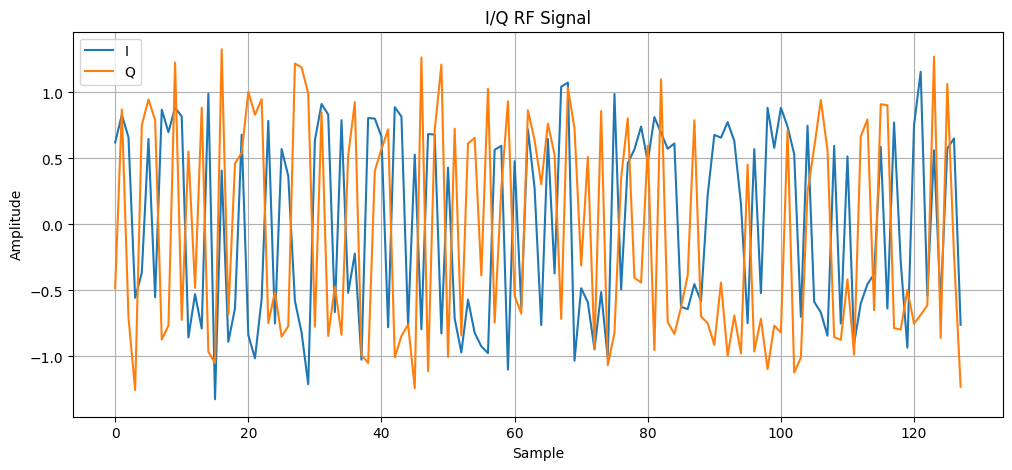

In [15]:
sample = X_train[0]

plt.figure(figsize=(12, 5))

plt.plot(sample[:, 0], label="I")
plt.plot(sample[:, 1], label="Q")

plt.title("I/Q RF Signal")
plt.xlabel("Sample")
plt.ylabel("Amplitude")

plt.legend()
plt.grid()

plt.show()

CNN model

In [16]:
cnn = Sequential([

    Input(shape=(SAMPLES, 2)),

    Conv1D(
        filters=32,
        kernel_size=3,
        activation="relu"
    ),

    BatchNormalization(),

    MaxPooling1D(pool_size=2),

    Conv1D(
        filters=64,
        kernel_size=3,
        activation="relu"
    ),

    BatchNormalization(),

    MaxPooling1D(pool_size=2),

    Conv1D(
        filters=128,
        kernel_size=3,
        activation="relu"
    ),

    BatchNormalization(),

    GlobalAveragePooling1D(),

    Dense(128, activation="relu"),

    Dropout(0.3),

    Dense(NUM_CLASSES, activation="softmax")
])

cnn.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 126, 32)        │           224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 126, 32)        │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 63, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 61, 64)         │         6,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 61, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 30, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 28, 128)        │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 28, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 49,060 (191.64 KB)

 Trainable params: 48,612 (189.89 KB)

 Non-trainable params: 448 (1.75 KB)

Compile the CNN



In [17]:
cnn.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

print("CNN compiled successfully")

CNN compiled successfully


Train the model

In [18]:
early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=2,
    min_lr=1e-6
)

history = cnn.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=30,
    batch_size=64,
    callbacks=[
        early_stopping,
        reduce_lr
    ],
    verbose=1
)

Epoch 1/30
88/88 ━━━━━━━━━━━━━━━━━━━━ 8s 60ms/step - accuracy: 0.6082 - loss: 0.8132 - val_accuracy: 0.4800 - val_loss: 1.0983 - learning_rate: 0.0010
Epoch 2/30
88/88 ━━━━━━━━━━━━━━━━━━━━ 4s 44ms/step - accuracy: 0.7561 - loss: 0.5074 - val_accuracy: 0.4400 - val_loss: 1.3493 - learning_rate: 0.0010
Epoch 3/30
88/88 ━━━━━━━━━━━━━━━━━━━━ 3s 38ms/step - accuracy: 0.8118 - loss: 0.4165 - val_accuracy: 0.5408 - val_loss: 1.0844 - learning_rate: 0.0010
Epoch 4/30
88/88 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - accuracy: 0.8382 - loss: 0.3648 - val_accuracy: 0.6925 - val_loss: 0.7703 - learning_rate: 0.0010
Epoch 5/30
88/88 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - accuracy: 0.8618 - loss: 0.3182 - val_accuracy: 0.7900 - val_loss: 0.5080 - learning_rate: 0.0010
Epoch 6/30
88/88 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.8764 - loss: 0.2810 - val_accuracy: 0.7783 - val_loss: 0.6054 - learning_rate: 0.0010
Epoch 7/30
88/88 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.8979 - loss: 0.2470 - val_acc

Plot training accuracy

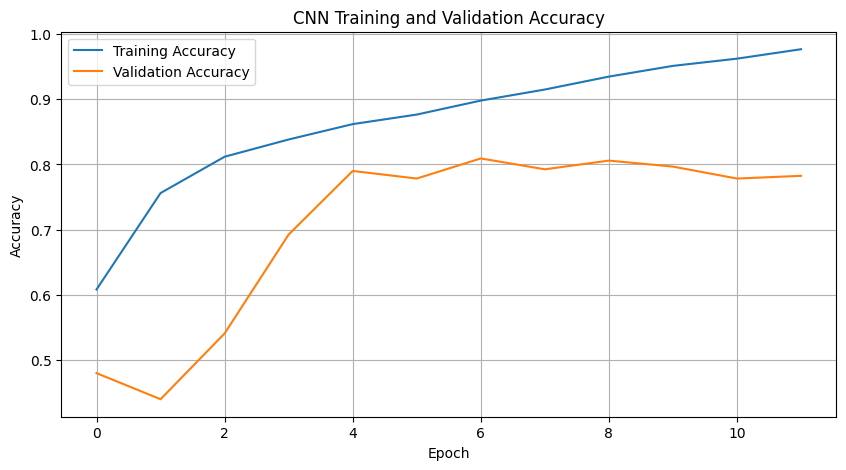

In [19]:
plt.figure(figsize=(10, 5))

plt.plot(
    history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.title("CNN Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend()
plt.grid()

plt.show()

Test the trained model

In [20]:
test_loss, test_accuracy = cnn.evaluate(
    X_test,
    y_test,
    verbose=0
)

print("Test Accuracy:", test_accuracy)
print("Test Accuracy (%):", test_accuracy * 100)

Test Accuracy: 0.8149999976158142
Test Accuracy (%): 81.49999976158142


Generate predictions

In [21]:
y_pred = cnn.predict(X_test)

y_pred_classes = np.argmax(y_pred, axis=1)
y_true_classes = np.argmax(y_test, axis=1)

print("Predictions generated successfully")

38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
Predictions generated successfully


Classification report

In [22]:
print(
    classification_report(
        y_true_classes,
        y_pred_classes,
        target_names=CLASS_NAMES
    )
)

              precision    recall  f1-score   support

        BPSK       0.99      0.94      0.97       300
        QPSK       0.73      0.76      0.74       300
      16-QAM       0.89      0.58      0.71       300
        BFSK       0.72      0.98      0.83       300

    accuracy                           0.81      1200
   macro avg       0.83      0.82      0.81      1200
weighted avg       0.83      0.81      0.81      1200



Confusion Matrix

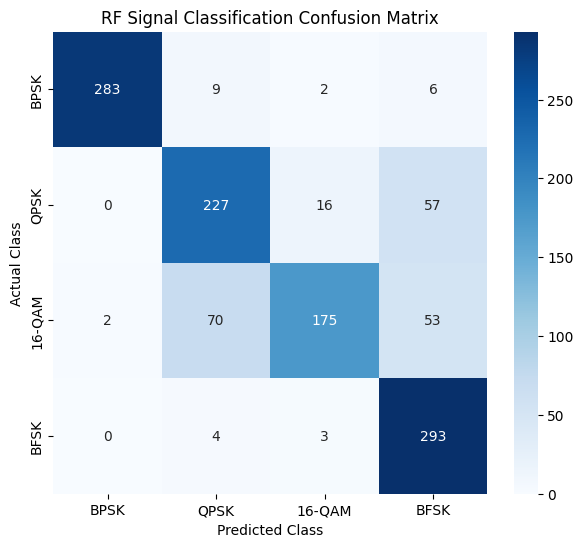

In [23]:
cm = confusion_matrix(
    y_true_classes,
    y_pred_classes
)

plt.figure(figsize=(7, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=CLASS_NAMES,
    yticklabels=CLASS_NAMES,
    cmap="Blues"
)

plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.title("RF Signal Classification Confusion Matrix")

plt.show()

Save your trained model

In [24]:
cnn.save("rf_signal_classifier.keras")

print("Model saved successfully!")

Model saved successfully!


In [25]:
from google.colab import files

files.download("rf_signal_classifier.keras")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [26]:
import tensorflow as tf
import keras

print("TensorFlow:", tf.__version__)
print("Keras:", keras.__version__)

TensorFlow: 2.20.0
Keras: 3.13.2


In [27]:
cnn.save("rf_signal_classifier.keras")
print("Model saved successfully")

Model saved successfully


In [28]:
import tensorflow as tf

model = tf.keras.models.load_model("rf_signal_classifier.keras")

print("Model loaded successfully!")

Model loaded successfully!


In [29]:
CLASS_NAMES = [
    "BPSK",
    "QPSK",
    "16-QAM",
    "BFSK"
]

print("Classes:", CLASS_NAMES)

Classes: ['BPSK', 'QPSK', '16-QAM', 'BFSK']


In [30]:
# Create a test input with 128 samples and 2 channels (I and Q)
test_input = np.random.randn(128, 2).astype(np.float32)

# Add batch dimension
test_input = np.expand_dims(test_input, axis=0)

# Predict
prediction = model.predict(test_input, verbose=0)

# Get predicted class
predicted_index = np.argmax(prediction[0])
predicted_class = CLASS_NAMES[predicted_index]
confidence = prediction[0][predicted_index] * 100

print("Predicted Signal:", predicted_class)
print("Confidence:", round(confidence, 2), "%")

Predicted Signal: 16-QAM
Confidence: 77.46 %


In [31]:
from flask import Flask, render_template_string, request, jsonify
from google.colab.output import eval_js
from IPython.display import display, HTML

app = Flask(__name__)

HTML_PAGE = """
<!DOCTYPE html>
<html>
<head>
    <title>RF Signal Classification</title>
    <style>
        body {
            font-family: Arial;
            text-align: center;
            margin-top: 50px;
        }

        h1 {
            color: #333;
        }

        button {
            padding: 12px 25px;
            font-size: 16px;
            cursor: pointer;
        }

        #result {
            margin-top: 25px;
            font-size: 20px;
        }
    </style>
</head>

<body>

    <h1>RF Signal Classification</h1>

    <p>Test the trained CNN model</p>

    <button onclick="classifySignal()">
        Classify Signal
    </button>

    <div id="result">
        Result will appear here
    </div>

<script>

function classifySignal() {

    document.getElementById("result").innerHTML =
        "Classification request sent...";

    fetch("/predict", {
        method: "POST",
        headers: {
            "Content-Type": "application/json"
        },
        body: JSON.stringify({
            iq: Array.from(
                {length: 128},
                () => [Math.random(), Math.random()]
            )
        })
    })

    .then(response => response.json())

    .then(data => {

        if (data.error) {
            document.getElementById("result").innerHTML =
                "Error: " + data.error;
        }
        else {
            document.getElementById("result").innerHTML =
                "<b>Predicted Signal:</b> " +
                data.predicted_class +
                "<br><br>" +
                "<b>Confidence:</b> " +
                data.confidence +
                "%";
        }

    });

}

</script>

</body>
</html>
"""

@app.route("/")
def home():
    return render_template_string(HTML_PAGE)


@app.route("/predict", methods=["POST"])
def predict():

    try:

        data = request.get_json()

        iq_data = np.array(data["iq"], dtype=np.float32)

        if iq_data.shape != (128, 2):
            return jsonify({
                "error": "Input must have shape (128, 2)"
            }), 400

        input_data = np.expand_dims(iq_data, axis=0)

        prediction = model.predict(input_data, verbose=0)

        predicted_index = int(np.argmax(prediction[0]))

        confidence = float(
            prediction[0][predicted_index] * 100
        )

        return jsonify({
            "predicted_class": CLASS_NAMES[predicted_index],
            "confidence": round(confidence, 2)
        })

    except Exception as e:

        return jsonify({
            "error": str(e)
        }), 500

In [32]:
from flask import Flask, jsonify, request, render_template
import numpy as np
import tensorflow as tf

app = Flask(__name__)

# Load model
model = tf.keras.models.load_model("rf_signal_classifier.keras")

CLASS_NAMES = [
    "BPSK",
    "QPSK",
    "16-QAM",
    "BFSK"
]

@app.route("/")
def home():
    return "RF Signal Classification Model is Running!"

@app.route("/model-status")
def model_status():
    return jsonify({
        "status": "success",
        "message": "CNN model loaded successfully",
        "classes": CLASS_NAMES
    })

print("Flask backend ready!")

Flask backend ready!


In [33]:
from flask import Flask

print("Starting Flask server...")

Starting Flask server...


In [34]:
from google.colab.output import serve_kernel_port_as_window

serve_kernel_port_as_window(5000)

Try `serve_kernel_port_as_iframe` instead. 


<IPython.core.display.Javascript object>

In [35]:
import threading

def run_flask():
    app.run(host="0.0.0.0", port=5000, debug=False)

thread = threading.Thread(target=run_flask)
thread.start()

print("Flask server started!")

Flask server started!


In [36]:
from google.colab.output import serve_kernel_port_as_iframe

serve_kernel_port_as_iframe(5000)

<IPython.core.display.Javascript object>

In [38]:
import requests

response = requests.get("http://127.0.0.1:5000/model-status")

print(response.status_code)
print(response.json())

INFO:werkzeug:127.0.0.1 - - [17/Sep/2026 04:47:24] "GET /model-status HTTP/1.1" 200 -


200
{'classes': ['BPSK', 'QPSK', '16-QAM', 'BFSK'], 'message': 'CNN model loaded successfully', 'status': 'success'}


In [39]:
from flask import Flask, jsonify, request
import numpy as np
import tensorflow as tf

app2 = Flask(__name__)

# Load trained model
model2 = tf.keras.models.load_model("rf_signal_classifier.keras")

CLASS_NAMES = [
    "BPSK",
    "QPSK",
    "16-QAM",
    "BFSK"
]

@app2.route("/")
def home2():
    return "RF Signal Classification Model is Running!"

@app2.route("/model-status")
def status2():
    return jsonify({
        "status": "success",
        "message": "CNN model loaded successfully",
        "classes": CLASS_NAMES
    })

@app2.route("/predict", methods=["POST"])
def predict2():

    try:
        data = request.get_json()

        iq_data = np.array(data["iq"], dtype=np.float32)

        if iq_data.shape != (128, 2):
            return jsonify({
                "error": "Input must have shape (128, 2)"
            }), 400

        input_data = np.expand_dims(iq_data, axis=0)

        prediction = model2.predict(input_data, verbose=0)

        predicted_class = int(np.argmax(prediction[0]))
        confidence = float(prediction[0][predicted_class])

        return jsonify({
            "predicted_class": CLASS_NAMES[predicted_class],
            "confidence": round(confidence * 100, 2)
        })

    except Exception as e:
        return jsonify({
            "error": str(e)
        }), 500


print("New Flask application is ready!")

New Flask application is ready!


In [40]:
import threading

def start_server():
    app2.run(host="0.0.0.0", port=5001, debug=False)

server_thread = threading.Thread(target=start_server)
server_thread.start()

print("Flask server started on port 5001!")

 * Serving Flask app '__main__'
 * Debug mode: off
Flask server started on port 5001!


INFO:werkzeug:WARNING: This is a development server. Do not use it in a production deployment. Use a production WSGI server instead.
 * Running on all addresses (0.0.0.0)
 * Running on http://127.0.0.1:5001
 * Running on http://172.28.0.12:5001
INFO:werkzeug:Press CTRL+C to quit


In [41]:
import numpy as np
import requests

# Create test I/Q signal
test_iq = np.random.randn(128, 2).tolist()

# Send to Flask
response = requests.post(
    "http://127.0.0.1:5001/predict",
    json={"iq": test_iq}
)

print("Status Code:", response.status_code)
print("Prediction:", response.text)

INFO:werkzeug:127.0.0.1 - - [17/Sep/2026 04:47:45] "POST /predict HTTP/1.1" 200 -


Status Code: 200
Prediction: {"confidence":86.16,"predicted_class":"BFSK"}



In [42]:
from flask import Flask, render_template_string, request, jsonify
import numpy as np
import threading

app_frontend = Flask(__name__)

HTML_PAGE = """
<!DOCTYPE html>
<html>
<head>
    <title>RF Signal Classification</title>
</head>

<body>
    <h1>RF Signal Classification</h1>

    <button onclick="classifySignal()">Classify Test Signal</button>

    <h2 id="result">Result will appear here</h2>

    <script>
    async function classifySignal() {

        // Create test I/Q signal
        let iq = [];

        for (let i = 0; i < 128; i++) {
            iq.push([
                Math.random(),
                Math.random()
            ]);
        }

        const response = await fetch("/predict", {
            method: "POST",
            headers: {
                "Content-Type": "application/json"
            },
            body: JSON.stringify({iq: iq})
        });

        const result = await response.json();

        document.getElementById("result").innerHTML =
            "Predicted Signal: " + result.predicted_class +
            "<br>Confidence: " + result.confidence + "%";
    }
    </script>

</body>
</html>
"""

@app_frontend.route("/")
def home():
    return render_template_string(HTML_PAGE)

# Assuming a model is loaded in an existing app (e.g., app2, app4)
# For this frontend to work with a backend, it needs to know the backend's port and route.
# If this is meant to be a standalone frontend for another backend service,
# the fetch URL in the HTML's JavaScript needs to be updated to point to the correct backend endpoint.
# For example, if app2 (running on port 5001) is the target backend, the fetch URL should be:
# `const response = await fetch("http://127.0.0.1:5001/predict", { ... })`
# For demonstration purposes, I will also add a dummy /predict route to this frontend
# or assume it's connecting to a running backend on a known port (e.g., 5001 from app2)

# Adding a dummy /predict route for local testing within this app_frontend
# In a real scenario, this frontend would likely call a separate backend API.
# For now, I'll assume the frontend part of the HTML will be changed to call an existing backend like app2 on port 5001.
# Therefore, this Flask instance will primarily serve the HTML.

# Start the frontend server on a new port (e.g., 5005) to avoid conflicts
def run_frontend_server():
    app_frontend.run(host="0.0.0.0", port=5005, debug=False, use_reloader=False)

frontend_thread = threading.Thread(target=run_frontend_server)
frontend_thread.daemon = True
frontend_thread.start()

print("Frontend code is ready and server starting on port 5005!")

Frontend code is ready and server starting on port 5005!
 * Serving Flask app '__main__'
 * Debug mode: off


In [43]:
# ==========================================
# RF SIGNAL CLASSIFICATION - COLAB WEB APP
# ==========================================

from flask import Flask, request, jsonify, render_template_string
import numpy as np
import tensorflow as tf
import threading
import time

# ------------------------------------------------
# 1. Class names
# ------------------------------------------------

CLASS_NAMES = [
    "BPSK",
    "QPSK",
    "16-QAM",
    "BFSK"
]

# ------------------------------------------------
# 2. Load trained model
# ------------------------------------------------

MODEL_PATH = "rf_signal_classifier.keras"

model = tf.keras.models.load_model(MODEL_PATH)

print("CNN Model loaded successfully!")
print("Classes:", CLASS_NAMES)

# ------------------------------------------------
# 3. Create Flask application
# ------------------------------------------------

app2 = Flask(__name__)

# ------------------------------------------------
# 4. Frontend HTML
# ------------------------------------------------

HTML_PAGE = """
<!DOCTYPE html>

<html>

<head>

    <title>RF Signal Classification</title>

    <meta name="viewport"
          content="width=device-width, initial-scale=1">

    <style>

        body {
            font-family: Arial, sans-serif;
            background: #f2f2f2;
            text-align: center;
            padding: 40px;
        }

        .container {
            background: white;
            max-width: 700px;
            margin: auto;
            padding: 35px;
            border-radius: 15px;
            box-shadow: 0px 4px 15px rgba(0,0,0,0.15);
        }

        h1 {
            color: #222;
        }

        p {
            font-size: 18px;
        }

        button {
            background: #007bff;
            color: white;
            border: none;
            padding: 14px 25px;
            font-size: 18px;
            border-radius: 8px;
            cursor: pointer;
        }

        button:hover {
            background: #0056b3;
        }

        #result {
            margin-top: 30px;
            font-size: 22px;
            font-weight: bold;
        }

        #confidence {
            margin-top: 15px;
            font-size: 20px;
        }

        .classes {
            margin-top: 30px;
            font-size: 17px;
        }

    </style>

</head>


<body>

<div class="container">

    <h1>RF Signal Classification</h1>

    <p>
        CNN Based RF Signal Classification System
    </p>

    <p>
        Classes: BPSK, QPSK, 16-QAM, BFSK
    </p>

    <button onclick="classifySignal()">
        Classify Test Signal
    </button>

    <div id="result">
        Prediction will appear here
    </div>

    <div id="confidence">
    </div>

    <div class="classes">

        <b>Supported Signals:</b><br><br>

        BPSK &nbsp;&nbsp;
        QPSK &nbsp;&nbsp;
        16-QAM &nbsp;&nbsp;
        BFSK

    </div>

</div>


<script>

async function classifySignal() {

    document.getElementById("result").innerHTML =
        "Classifying signal...";

    document.getElementById("confidence").innerHTML =
        "";

    // -----------------------------------------
    // Create 128 x 2 I/Q test signal
    // -----------------------------------------

    let iq = [];

    for (let i = 0; i < 128; i++) {

        iq.push([
            Math.random() * 2 - 1,
            Math.random() * 2 - 1
        ]);

    }


    // -----------------------------------------
    // Send signal to Flask backend
    // -----------------------------------------

    try {

        const response = await fetch("/predict", {

            method: "POST",

            headers: {
                "Content-Type": "application/json"
            },

            body: JSON.stringify({
                iq: iq
            })

        });


        const result = await response.json();


        if (response.ok) {

            document.getElementById("result").innerHTML =
                "Predicted Signal: " +
                result.predicted_class;

            document.getElementById("confidence").innerHTML =
                "Confidence: " +
                result.confidence +
                "%";

        }

        else {

            document.getElementById("result").innerHTML =
                "Error: " + result.error;

        }

    }

    catch(error) {

        document.getElementById("result").innerHTML =
            "Backend connection error";

        console.log(error);

    }

}

</script>


</body>

</html>
"""


# ------------------------------------------------
# 5. Home page
# ------------------------------------------------

@app2.route("/")
def home():

    return render_template_string(HTML_PAGE)


# ------------------------------------------------
# 6. Model status
# ------------------------------------------------

@app2.route("/model-status")
def model_status():

    return jsonify({

        "status": "success",

        "message": "CNN model loaded successfully",

        "classes": CLASS_NAMES

    })


# ------------------------------------------------
# 7. Prediction API
# ------------------------------------------------

@app2.route("/predict", methods=["POST"])
def predict():

    try:

        data = request.get_json()

        if data is None or "iq" not in data:

            return jsonify({
                "error": "I/Q signal data not found"
            }), 400


        # Convert I/Q data to NumPy array

        iq_data = np.array(
            data["iq"],
            dtype=np.float32
        )


        # Check shape

        if iq_data.shape != (128, 2):

            return jsonify({

                "error":
                f"Expected shape (128, 2), "
                f"but received {iq_data.shape}"

            }), 400


        # Add batch dimension

        input_data = np.expand_dims(
            iq_data,
            axis=0
        )


        # Model prediction

        prediction = model.predict(
            input_data,
            verbose=0
        )


        # Find predicted class

        predicted_index = int(
            np.argmax(prediction[0])
        )


        predicted_class = CLASS_NAMES[
            predicted_index
        ]


        confidence = float(
            prediction[0][predicted_index]
        ) * 100


        return jsonify({

            "predicted_class":
                predicted_class,

            "confidence":
                round(confidence, 2)

        })


    except Exception as e:

        return jsonify({

            "error": str(e)

        }), 500


# ------------------------------------------------
# 8. Start Flask server
# ------------------------------------------------

def run_server():

    app2.run(
        host="0.0.0.0",
        port=5002,
        debug=False,
        use_reloader=False
    )


server_thread = threading.Thread(
    target=run_server,
    daemon=True
)

server_thread.start()


time.sleep(3)

print("====================================")
print("RF Signal Classification Web App")
print("====================================")
print("Flask server started successfully!")
print("Port: 5002")
print("Ready to open the frontend!")

CNN Model loaded successfully!
Classes: ['BPSK', 'QPSK', '16-QAM', 'BFSK']
 * Serving Flask app '__main__'
 * Debug mode: off


INFO:werkzeug:WARNING: This is a development server. Do not use it in a production deployment. Use a production WSGI server instead.
 * Running on all addresses (0.0.0.0)
 * Running on http://127.0.0.1:5002
 * Running on http://172.28.0.12:5002
INFO:werkzeug:Press CTRL+C to quit


RF Signal Classification Web App
Flask server started successfully!
Port: 5002
Ready to open the frontend!


In [44]:
from google.colab.output import serve_kernel_port_as_iframe

serve_kernel_port_as_iframe(5002)

<IPython.core.display.Javascript object>

In [45]:
import numpy as np
import pandas as pd

# Create sample I/Q signal
np.random.seed(42)

I = np.random.randn(128)
Q = np.random.randn(128)

# Create CSV
sample_iq = pd.DataFrame({
    "I": I,
    "Q": Q
})

sample_iq.to_csv("sample_IQ_signal.csv", index=False)

print("Sample I/Q CSV created successfully!")
print("Shape:", sample_iq.shape)
print(sample_iq.head())

Sample I/Q CSV created successfully!
Shape: (128, 2)
          I         Q
0  0.496714  0.099651
1 -0.138264 -0.503476
2  0.647689 -1.550663
3  1.523030  0.068563
4 -0.234153 -1.062304


In [46]:
# Read the sample CSV
data = pd.read_csv("sample_IQ_signal.csv")

# Get I and Q values
iq_data = data.iloc[:, :2].values.astype(np.float32)

print("CSV loaded successfully!")
print("Shape:", iq_data.shape)

# Prepare input for CNN
input_data = np.expand_dims(iq_data, axis=0)

# Predict
prediction = model.predict(input_data, verbose=0)

predicted_index = int(np.argmax(prediction[0]))
predicted_class = CLASS_NAMES[predicted_index]

confidence = float(prediction[0][predicted_index]) * 100

print()
print("Predicted Signal:", predicted_class)
print("Confidence:", round(confidence, 2), "%")

CSV loaded successfully!
Shape: (128, 2)

Predicted Signal: QPSK
Confidence: 57.28 %


In [47]:
from flask import Flask, request, jsonify, render_template_string
import pandas as pd
import numpy as np
import tensorflow as tf

app3 = Flask(__name__)

# Load model
model3 = tf.keras.models.load_model("rf_signal_classifier.keras")

CLASS_NAMES = [
    "BPSK",
    "QPSK",
    "16-QAM",
    "BFSK"
]

# Web page
HTML_PAGE = """
<!DOCTYPE html>
<html>
<head>
    <title>RF Signal Classification</title>

    <style>
        body {
            font-family: Arial;
            text-align: center;
            margin-top: 50px;
        }

        .box {
            width: 500px;
            margin: auto;
            padding: 30px;
            border: 1px solid #ccc;
            border-radius: 15px;
        }

        button {
            padding: 12px 25px;
            font-size: 16px;
            cursor: pointer;
            margin-top: 15px;
        }

        #result {
            margin-top: 25px;
            font-size: 20px;
        }
    </style>
</head>

<body>

<div class="box">

    <h1>RF Signal Classification</h1>

    <h3>CNN Based RF Signal Classification System</h3>

    <p><b>Supported Signals:</b></p>
    <p>BPSK | QPSK | 16-QAM | BFSK</p>

    <hr>

    <h3>Upload I/Q CSV Signal</h3>

    <input type="file" id="fileInput" accept=".csv">

    <br>

    <button onclick="classifySignal()">
        Classify Signal
    </button>

    <div id="result"></div>

</div>

<script>

function classifySignal() {

    const fileInput = document.getElementById("fileInput");
    const result = document.getElementById("result");

    if (fileInput.files.length === 0) {
        result.innerHTML = "Please select a CSV file.";
        return;
    }

    const file = fileInput.files[0];

    const formData = new FormData();
    formData.append("file", file);

    result.innerHTML = "Classifying signal...";

    fetch("/predict-file", {
        method: "POST",
        body: formData
    })

    .then(response => response.json())

    .then(data => {

        if (data.error) {
            result.innerHTML =
                "<b>Error:</b> " + data.error;
        }
        else {
            result.innerHTML =
                "<b>Predicted Signal:</b> "
                + data.predicted_class
                + "<br><br>"
                + "<b>Confidence:</b> "
                + data.confidence
                + "%";
        }

    })

    .catch(error => {

        result.innerHTML =
            "<b>Error:</b> Unable to connect to server.";

    });

}

</script>

</body>
</html>
"""


# Home page
@app3.route("/")
def home3():
    return render_template_string(HTML_PAGE)


# Model status
@app3.route("/model-status")
def model_status3():

    return jsonify({
        "status": "success",
        "message": "CNN model loaded successfully",
        "classes": CLASS_NAMES
    })


# CSV prediction
@app3.route("/predict-file", methods=["POST"])
def predict_file():

    try:

        # Check file
        if "file" not in request.files:
            return jsonify({
                "error": "No CSV file uploaded."
            }), 400

        file = request.files["file"]

        # Read CSV
        data = pd.read_csv(file)

        # Take first two columns as I and Q
        iq_data = data.iloc[:, :2].values.astype(np.float32)

        # Check shape
        if iq_data.shape != (128, 2):

            return jsonify({
                "error": "CSV must contain exactly 128 rows and 2 columns."
            }), 400

        # Prepare CNN input
        input_data = np.expand_dims(iq_data, axis=0)

        # Prediction
        prediction = model3.predict(
            input_data,
            verbose=0
        )

        predicted_index = int(
            np.argmax(prediction[0])
        )

        predicted_class = CLASS_NAMES[
            predicted_index
        ]

        confidence = float(
            prediction[0][predicted_index]
        ) * 100

        return jsonify({

            "predicted_class":
                predicted_class,

            "confidence":
                round(confidence, 2)

        })

    except Exception as e:

        return jsonify({
            "error": str(e)
        }), 500


# Start server
app3.run(
    host="0.0.0.0",
    port=5003,
    debug=False,
    use_reloader=False
)

 * Serving Flask app '__main__'
 * Debug mode: off


INFO:werkzeug:WARNING: This is a development server. Do not use it in a production deployment. Use a production WSGI server instead.
 * Running on all addresses (0.0.0.0)
 * Running on http://127.0.0.1:5003
 * Running on http://172.28.0.12:5003
INFO:werkzeug:Press CTRL+C to quit


In [48]:
from google.colab.output import serve_kernel_port_as_iframe

serve_kernel_port_as_iframe(5003)

<IPython.core.display.Javascript object>

In [50]:
import threading

def run_flask():
    app3.run(
        host="0.0.0.0",
        port=5003,
        debug=False,
        use_reloader=False
    )

thread = threading.Thread(target=run_flask)
thread.daemon = True
thread.start()

print("Flask server started successfully!")

Flask server started successfully!
 * Serving Flask app '__main__'
 * Debug mode: off


Address already in use
Port 5003 is in use by another program. Either identify and stop that program, or start the server with a different port.


In [51]:
from google.colab.output import serve_kernel_port_as_iframe

serve_kernel_port_as_iframe(5003)

<IPython.core.display.Javascript object>

In [52]:
from google.colab import files

files.download("sample_IQ_signal.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [53]:
# Save the normalization values used during training

np.savez(
    "normalization.npz",
    mean=mean,
    std=std
)

print("Normalization values saved successfully!")

Normalization values saved successfully!


In [54]:
# Load saved normalization values

norm = np.load("normalization.npz")

mean_saved = norm["mean"].squeeze()
std_saved = norm["std"].squeeze()

print("Normalization loaded successfully!")
print("Mean shape:", mean_saved.shape)
print("Std shape:", std_saved.shape)

Normalization loaded successfully!
Mean shape: (2,)
Std shape: (2,)


In [55]:
# Create updated RF Signal Classification portal
# with proper normalization

from flask import Flask, request, jsonify, render_template_string
import pandas as pd
import numpy as np
import tensorflow as tf

app4 = Flask(__name__)

# Load model
model4 = tf.keras.models.load_model("rf_signal_classifier.keras")

CLASS_NAMES = ["BPSK", "QPSK", "16-QAM", "BFSK"]

# Load normalization values
norm = np.load("normalization.npz")
mean_saved = norm["mean"].squeeze()
std_saved = norm["std"].squeeze()


HTML_PAGE_4 = """
<!DOCTYPE html>
<html>
<head>
    <title>RF Signal Classification</title>

    <style>
        body {
            font-family: Arial;
            text-align: center;
            margin-top: 50px;
        }

        .box {
            width: 550px;
            margin: auto;
            padding: 30px;
            border: 1px solid #ccc;
            border-radius: 15px;
        }

        button {
            padding: 12px 25px;
            font-size: 16px;
            cursor: pointer;
            margin-top: 15px;
        }

        #result {
            margin-top: 25px;
            font-size: 20px;
        }
    </style>
</head>

<body>

<div class="box">

    <h1>RF Signal Classification</h1>

    <h3>CNN Based RF Signal Classification System</h3>

    <p><b>Supported Signals:</b></p>

    <p>BPSK | QPSK | 16-QAM | BFSK</p>

    <hr>

    <h3>Upload I/Q CSV Signal</h3>

    <input type="file" id="fileInput" accept=".csv">

    <br>

    <button onclick="classifySignal()">
        Classify Signal
    </button>

    <div id="result"></div>

</div>


<script>

function classifySignal() {

    const fileInput =
        document.getElementById("fileInput");

    const result =
        document.getElementById("result");

    if (fileInput.files.length === 0) {

        result.innerHTML =
            "Please select a CSV file.";

        return;
    }

    const file = fileInput.files[0];

    const formData = new FormData();

    formData.append("file", file);

    result.innerHTML =
        "Classifying signal...";

    fetch("/predict-file", {

        method: "POST",

        body: formData

    })

    .then(response => response.json())

    .then(data => {

        if (data.error) {

            result.innerHTML =
                "<b>Error:</b> " +
                data.error;

        } else {

            result.innerHTML =
                "<b>Predicted Signal:</b> " +
                data.predicted_class +
                "<br><br>" +
                "<b>Confidence:</b> " +
                data.confidence +
                "%";

        }

    })

    .catch(error => {

        result.innerHTML =
            "<b>Error:</b> Unable to connect to server.";

    });

}

</script>

</body>
</html>
"""


@app4.route("/")
def home4():

    return render_template_string(
        HTML_PAGE_4
    )


@app4.route("/predict-file", methods=["POST"])
def predict_file4():

    try:

        if "file" not in request.files:

            return jsonify({
                "error": "No CSV file uploaded."
            }), 400


        file = request.files["file"]


        # Read CSV
        data = pd.read_csv(file)


        # Take I and Q columns
        iq_data = data.iloc[:, :2].values.astype(
            np.float32
        )


        # Check correct size
        if iq_data.shape != (128, 2):

            return jsonify({
                "error":
                "CSV must contain exactly 128 rows and 2 columns."
            }), 400


        # Apply training normalization
        iq_data = (
            iq_data - mean_saved
        ) / (
            std_saved + 1e-8
        )


        # Prepare CNN input
        input_data = np.expand_dims(
            iq_data,
            axis=0
        )


        # Prediction
        prediction = model4.predict(
            input_data,
            verbose=0
        )


        predicted_index = int(
            np.argmax(prediction[0])
        )


        predicted_class = CLASS_NAMES[
            predicted_index
        ]


        confidence = (
            float(
                prediction[0][predicted_index]
            ) * 100
        )


        return jsonify({

            "predicted_class":
                predicted_class,

            "confidence":
                round(confidence, 2)

        })


    except Exception as e:

        return jsonify({
            "error": str(e)
        }), 500


print("Updated RF portal is ready!")

Updated RF portal is ready!


In [56]:
import threading

def run_updated_flask():
    app4.run(
        host="0.0.0.0",
        port=5004,
        debug=False,
        use_reloader=False
    )

thread4 = threading.Thread(
    target=run_updated_flask
)

thread4.daemon = True
thread4.start()

print("Updated RF server started successfully!")

Updated RF server started successfully!
 * Serving Flask app '__main__'
 * Debug mode: off


In [57]:
from google.colab.output import serve_kernel_port_as_iframe

serve_kernel_port_as_iframe(5004)

<IPython.core.display.Javascript object>

In [58]:
import threading

def run_app5():
    ...

In [59]:
import threading

def run_app5():
    app5.run(
        host="0.0.0.0",
        port=5005,
        debug=False,
        use_reloader=False
    )

thread5 = threading.Thread(target=run_app5)
thread5.daemon = True
thread5.start()

print("RF Graph Portal started successfully!")

RF Graph Portal started successfully!


Exception in thread Thread-22 (run_app5):
Traceback (most recent call last):
  File "/usr/lib/python3.13/threading.py", line 1044, in _bootstrap_inner
    self.run()
    ~~~~~~~~^^
  File "/usr/lib/python3.13/threading.py", line 995, in run
    self._target(*self._args, **self._kwargs)
    ~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/tmp/ipykernel_696/822445525.py", line 4, in run_app5
    app5.run(
    ^^^^
NameError: name 'app5' is not defined. Did you mean: 'app'?


In [61]:
# ==========================================================
# RF SIGNAL CLASSIFICATION - COLAB WEB PORTAL
# ==========================================================

from flask import Flask, request, jsonify, render_template_string
import pandas as pd
import numpy as np
import tensorflow as tf
import threading

# ----------------------------------------------------------
# 1. Flask App
# ----------------------------------------------------------

app6 = Flask(__name__)

# ----------------------------------------------------------
# 2. Load trained model
# ----------------------------------------------------------

model6 = tf.keras.models.load_model("rf_signal_classifier.keras")

CLASS_NAMES = ["BPSK", "QPSK", "16-QAM", "BFSK"]

# ----------------------------------------------------------
# 3. Load normalization values
# ----------------------------------------------------------

norm = np.load("normalization.npz")

mean_saved = norm["mean"].squeeze()
std_saved = norm["std"].squeeze()

print("Model loaded successfully!")
print("Normalization values loaded successfully!")

# ----------------------------------------------------------
# 4. Web Portal HTML
# ----------------------------------------------------------

HTML = """
<!DOCTYPE html>

<html>

<head>

<title>RF Signal Classification</title>

<style>

body {
    font-family: Arial, sans-serif;
    background: #f2f2f2;
    margin: 0;
    padding: 30px;
}

.container {
    width: 700px;
    margin: auto;
    background: white;
    padding: 35px;
    border-radius: 12px;
    box-shadow: 0px 0px 10px #cccccc;
    text-align: center;
}

h1 {
    font-size: 34px;
    margin-bottom: 10px;
}

h2 {
    font-size: 22px;
}

.supported {
    font-size: 18px;
    margin: 20px;
}

hr {
    margin: 25px 0;
}

input {
    margin: 15px;
    font-size: 16px;
}

button {
    padding: 12px 25px;
    font-size: 18px;
    border-radius: 6px;
    border: 1px solid #888;
    cursor: pointer;
}

button:hover {
    background: #eeeeee;
}

#result {
    margin-top: 25px;
    font-size: 22px;
}

#chartArea {
    margin-top: 25px;
}

canvas {
    border: 1px solid #cccccc;
    margin-top: 10px;
    max-width: 100%;
}

.bar {
    height: 25px;
    background: #dddddd;
    margin: 8px 0;
    border-radius: 5px;
    overflow: hidden;
}

.fill {
    height: 100%;
    background: #777777;
    color: white;
    text-align: left;
    padding-left: 8px;
    line-height: 25px;
}

</style>

</head>


<body>

<div class="container">

<h1>RF Signal Classification</h1>

<h2>CNN Based RF Signal Classification System</h2>

<div class="supported">

<b>Supported Signals:</b>

<br><br>

BPSK | QPSK | 16-QAM | BFSK

</div>

<hr>

<h2>Upload I/Q CSV Signal</h2>

<input type="file" id="fileInput" accept=".csv">

<br>

<button onclick="classifySignal()">

Classify Signal

</button>

<div id="result"></div>

<div id="chartArea"></div>

</div>


<script>

async function classifySignal() {

    const fileInput = document.getElementById("fileInput");

    const result = document.getElementById("result");

    const chartArea = document.getElementById("chartArea");

    if (fileInput.files.length === 0) {

        result.innerHTML =
        "<b>Please select a CSV file.</b>";

        return;
    }

    const file = fileInput.files[0];

    const formData = new FormData();

    formData.append("file", file);

    result.innerHTML = "Classifying signal...";

    chartArea.innerHTML = "";

    try {

        // IMPORTANT:
        // Relative URL works correctly inside Colab iframe

        const response = await fetch("/predict-file", {

            method: "POST",

            body: formData

        });

        const data = await response.json();

        if (!response.ok) {

            result.innerHTML =
            "<b>Error:</b> " + data.error;

            return;

        }

        result.innerHTML =

        "<b>Predicted Signal:</b> " +
        data.predicted_class +

        "<br><br>" +

        "<b>Confidence:</b> " +
        data.confidence.toFixed(2) +
        "%";


        // --------------------------------------------------
        // Waveform
        // --------------------------------------------------

        let html = "<h3>I/Q Signal Waveform</h3>";

        html += '<canvas id="waveCanvas" width="600" height="250"></canvas>';

        html += "<h3>Classification Probabilities</h3>";

        for (let i = 0; i < data.classes.length; i++) {

            let value = data.probabilities[i];

            html +=

            "<div style='text-align:left'>" +

            data.classes[i] +

            " : " +

            value.toFixed(2) +

            "%</div>" +

            "<div class='bar'>" +

            "<div class='fill' style='width:" +

            value +

            "%'>" +

            value.toFixed(1) +

            "%" +

            "</div>" +

            "</div>";

        }

        chartArea.innerHTML = html;


        // --------------------------------------------------
        // Draw waveform
        // --------------------------------------------------

        const canvas =
        document.getElementById("waveCanvas");

        const ctx = canvas.getContext("2d");

        const I = data.I;
        const Q = data.Q;

        ctx.clearRect(
            0,
            0,
            canvas.width,
            canvas.height
        );

        // Draw center line

        ctx.beginPath();

        ctx.moveTo(0, canvas.height / 2);

        ctx.lineTo(
            canvas.width,
            canvas.height / 2
        );

        ctx.stroke();


        // Draw I signal

        ctx.beginPath();

        for (let i = 0; i < I.length; i++) {

            let x =
            i * canvas.width / (I.length - 1);

            let y =
            canvas.height / 4 -
            I[i] * 50;

            if (i === 0) {

                ctx.moveTo(x, y);

            } else {

                ctx.lineTo(x, y);

            }

        }

        ctx.stroke();


        // Draw Q signal

        ctx.beginPath();

        for (let i = 0; i < Q.length; i++) {

            let x =
            i * canvas.width / (Q.length - 1);

            let y =
            3 * canvas.height / 4 -
            Q[i] * 50;

            if (i === 0) {

                ctx.moveTo(x, y);

            } else {

                ctx.lineTo(x, y);

            }

        }

        ctx.stroke();

    }

    catch (error) {

        result.innerHTML =
        "<b>Error:</b> Unable to connect to server.";

        console.log(error);

    }

}

</script>

</body>

</html>
"""


# ----------------------------------------------------------
# 5. Home Page
# ----------------------------------------------------------

@app6.route("/")
def home():

    return render_template_string(HTML)


# ----------------------------------------------------------
# 6. Prediction API
# ----------------------------------------------------------

@app6.route("/predict-file", methods=["POST"])
def predict_file():

    try:

        if "file" not in request.files:

            return jsonify({
                "error": "No file uploaded"
            }), 400

        file = request.files["file"]

        # Read CSV

        df = pd.read_csv(file)

        # --------------------------------------------------
        # Check columns
        # --------------------------------------------------

        if "I" in df.columns and "Q" in df.columns:

            iq = df[["I", "Q"]].values

        else:

            iq = df.iloc[:, :2].values


        # Convert to float

        iq = iq.astype(np.float32)


        # --------------------------------------------------
        # Check shape
        # --------------------------------------------------

        if iq.shape != (128, 2):

            return jsonify({

                "error":
                "CSV must contain exactly 128 rows and 2 columns (I and Q)."

            }), 400


        # --------------------------------------------------
        # Normalize using training values
        # --------------------------------------------------

        iq_normalized = (
            iq - mean_saved
        ) / (
            std_saved + 1e-8
        )


        # --------------------------------------------------
        # Add batch dimension
        # --------------------------------------------------

        input_data = np.expand_dims(
            iq_normalized,
            axis=0
        )


        # --------------------------------------------------
        # Prediction
        # --------------------------------------------------

        prediction = model6.predict(
            input_data,
            verbose=0
        )[0]


        predicted_index = int(
            np.argmax(prediction)
        )

        predicted_class = CLASS_NAMES[
            predicted_index
        ]

        confidence = float(
            prediction[predicted_index] * 100
        )


        probabilities = (
            prediction * 100
        ).tolist()


        # --------------------------------------------------
        # Return result
        # --------------------------------------------------

        return jsonify({

            "predicted_class":
            predicted_class,

            "confidence":
            confidence,

            "classes":
            CLASS_NAMES,

            "probabilities":
            probabilities,

            "I":
            iq[:, 0].tolist(),

            "Q":
            iq[:, 1].tolist()

        })


    except Exception as e:

        return jsonify({

            "error": str(e)

        }), 500


# ----------------------------------------------------------
# 7. Start server
# ----------------------------------------------------------

def run_app6():

    app6.run(

        host="0.0.0.0",

        port=5006,

        debug=False,

        use_reloader=False

    )


thread6 = threading.Thread(
    target=run_app6
)

thread6.daemon = True

thread6.start()


print("======================================")
print("RF Signal Classification Portal Ready")
print("Server running on port 5006")
print("======================================")

Model loaded successfully!
Normalization values loaded successfully!
 * Serving Flask app '__main__'
 * Debug mode: off
RF Signal Classification Portal Ready
Server running on port 5006


INFO:werkzeug:WARNING: This is a development server. Do not use it in a production deployment. Use a production WSGI server instead.
 * Running on all addresses (0.0.0.0)
 * Running on http://127.0.0.1:5006
 * Running on http://172.28.0.12:5006
INFO:werkzeug:Press CTRL+C to quit


In [62]:
from google.colab.output import serve_kernel_port_as_iframe

serve_kernel_port_as_iframe(5006, height=850)

<IPython.core.display.Javascript object>